## Modelado del sistema con NARX (3 retardos)

En este notebook se aborda el modelado del sistema carrito-péndulo utilizando un enfoque NARX con 3 retardos. Para ello, se emplea un dataset combinado que integra diferentes tipos de excitación (chirp, random y control), con el objetivo de mejorar la capacidad de generalización del modelo.

Se entrenan dos tipos de modelos:
- Un modelo de regresión lineal como referencia (baseline)
- Un modelo no lineal basado en una red neuronal (MLP)

Ambos modelos se evalúan en predicción a un paso mediante el error cuadrático medio (MSE) y mediante la comparación visual entre valores reales y predichos. Esto permite analizar hasta qué punto la dinámica del sistema puede ser capturada mediante modelos lineales y no lineales.

Shape: (29994, 19)
MSE lineal: 0.010456299824304795
MSE MLP: 0.010107814819415981


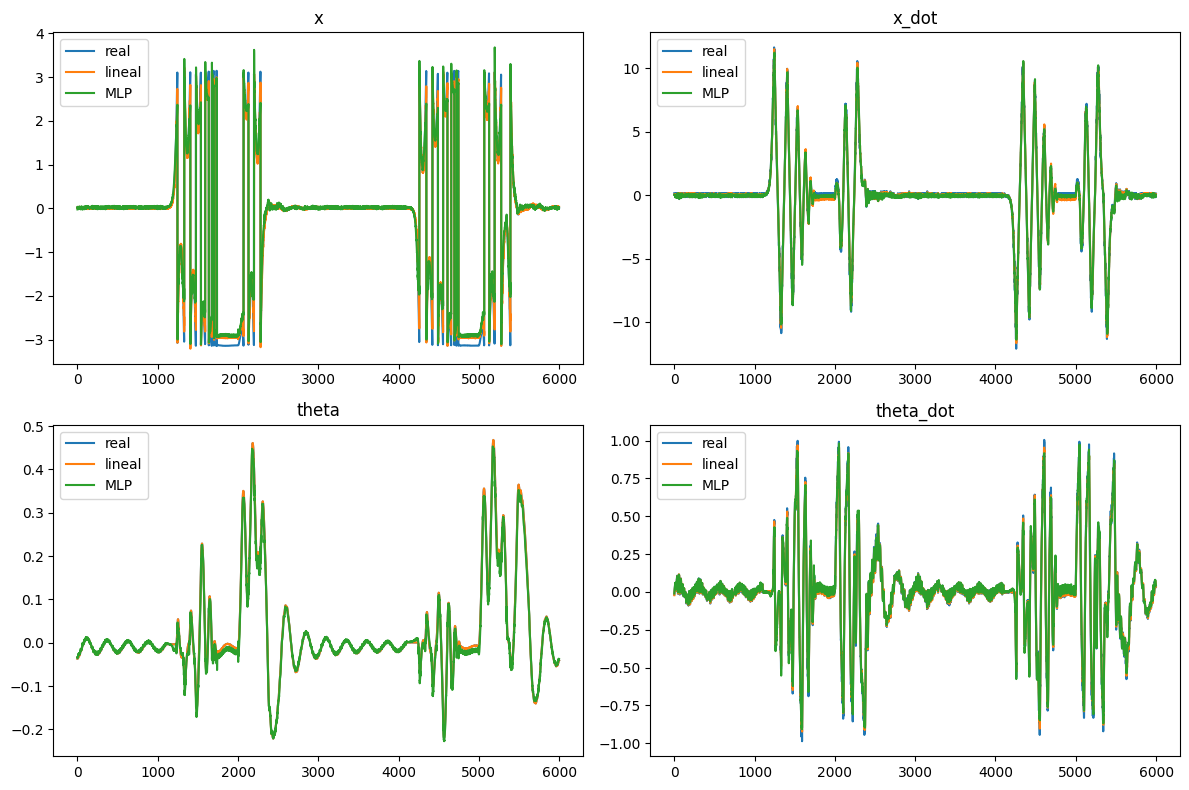

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# =========================
# CARGA Y LIMPIEZA
# =========================
df = pd.read_csv(r"C:\Users\alber\OneDrive\Desktop\control automático\control-autom-tico\Data\real\dataset_3_total.csv")

# eliminar cabeceras duplicadas
df = df[df["x_k"] != "x_k"]

# convertir a numérico
df = df.apply(pd.to_numeric)

print("Shape:", df.shape)

# =========================
# SEPARAR X e Y
# =========================
Y = df[["x_k", "x_dot_k", "theta_k", "theta_dot_k"]].values
X = df.drop(columns=["x_k", "x_dot_k", "theta_k", "theta_dot_k"]).values

# =========================
# SPLIT TEMPORAL
# =========================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# =========================
# NORMALIZACIÓN
# =========================
sx = StandardScaler()
sy = StandardScaler()

X_train = sx.fit_transform(X_train)
X_test = sx.transform(X_test)

Y_train = sy.fit_transform(Y_train)
Y_test = sy.transform(Y_test)

# =========================
# MODELO LINEAL
# =========================
lin = LinearRegression()
lin.fit(X_train, Y_train)

Y_pred_lin = lin.predict(X_test)
mse_lin = mean_squared_error(Y_test, Y_pred_lin)

print("MSE lineal:", mse_lin)

# =========================
# MODELO MLP
# =========================
mlp = MLPRegressor(hidden_layer_sizes=(32,32), max_iter=500, random_state=42)
mlp.fit(X_train, Y_train)

Y_pred_mlp = mlp.predict(X_test)
mse_mlp = mean_squared_error(Y_test, Y_pred_mlp)

print("MSE MLP:", mse_mlp)

# =========================
# DESNORMALIZAR
# =========================
Y_test_real = sy.inverse_transform(Y_test)
Y_lin_real = sy.inverse_transform(Y_pred_lin)
Y_mlp_real = sy.inverse_transform(Y_pred_mlp)

# =========================
# PLOT COMPARACIÓN
# =========================
labels = ["x", "x_dot", "theta", "theta_dot"]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(Y_test_real[:,i], label="real")
    plt.plot(Y_lin_real[:,i], label="lineal")
    plt.plot(Y_mlp_real[:,i], label="MLP")
    plt.title(labels[i])
    plt.legend()

plt.tight_layout()
plt.show()

## Análisis de resultados: modelo lineal vs MLP

Se comparan los resultados obtenidos mediante un modelo de regresión lineal y un modelo no lineal basado en una red neuronal (MLP) para la predicción a un paso del sistema.

De forma general, ambos modelos son capaces de aproximar adecuadamente la dinámica del sistema, lo que indica que una parte significativa del comportamiento puede ser capturada mediante relaciones lineales. Sin embargo, se observan diferencias relevantes en determinadas regiones:

- En las variables relacionadas con la posición del carrito (`x`) y su velocidad (`x_dot`), el modelo MLP muestra una mejor capacidad para seguir transiciones bruscas y picos, reduciendo errores en zonas de mayor variabilidad.
- En las variables del péndulo (`theta` y `theta_dot`), ambos modelos presentan un comportamiento muy similar, aunque el MLP ofrece una ligera mejora en la captura de oscilaciones y amplitudes.

En conjunto, el modelo MLP presenta una mejora respecto al modelo lineal, especialmente en regiones donde la dinámica del sistema es más no lineal. No obstante, esta mejora no es drástica, lo que sugiere que el sistema puede ser parcialmente descrito mediante modelos lineales en el contexto de predicción a un paso.

Este análisis pone de manifiesto la necesidad de evaluar los modelos en condiciones más exigentes, como la simulación recursiva, donde las diferencias entre modelos suelen hacerse más evidentes.

## Modelo base (predicción del último estado)

Se define un modelo base en el que la predicción del estado actual es igual al estado anterior:

y(k) = y(k-1)

Este modelo sirve como referencia para evaluar si los modelos de machine learning realmente aportan mejora.

MSE baseline: 0.06514276710731567


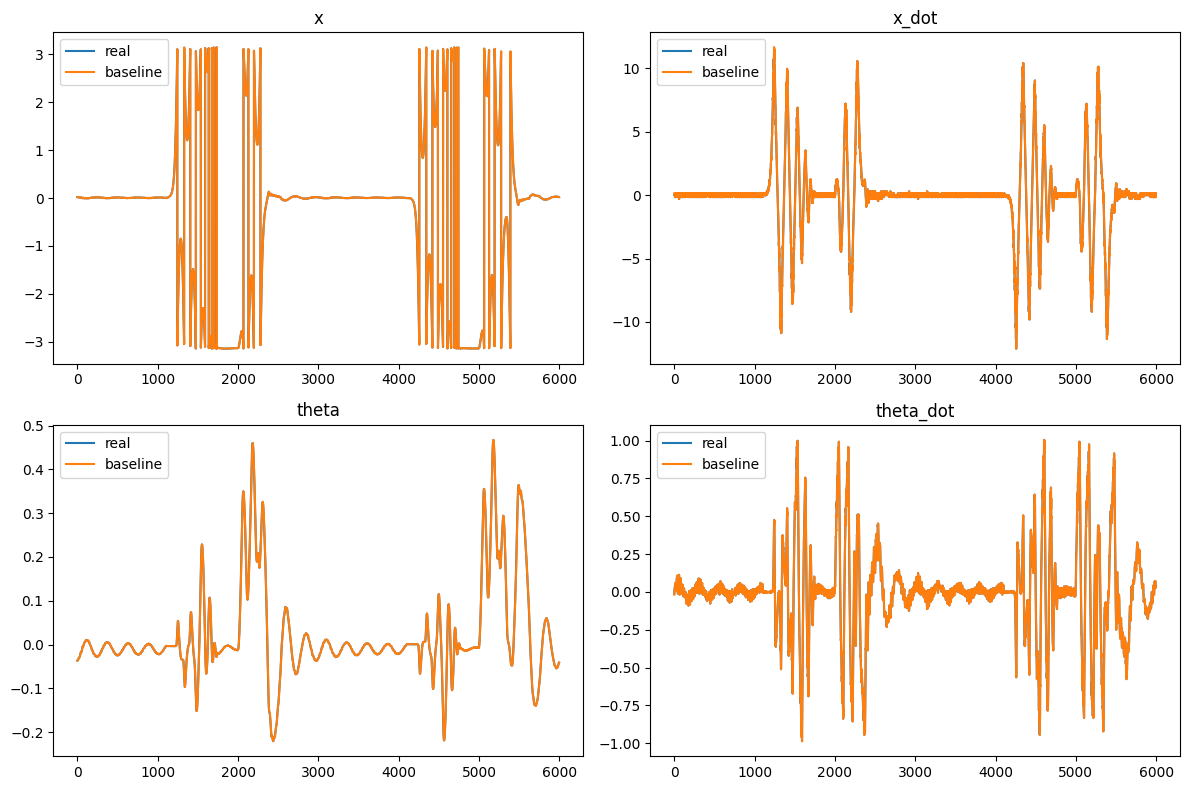

In [7]:
# =========================
# MODELO BASE
# =========================

# predicción: valor anterior
Y_pred_base = np.zeros_like(Y_test_real)

# desplazamiento temporal
Y_pred_base[1:] = Y_test_real[:-1]

# quitamos el primer punto (no válido)
Y_pred_base_valid = Y_pred_base[1:]
Y_test_base_valid = Y_test_real[1:]

# =========================
# MSE BASE
# =========================
mse_base = mean_squared_error(Y_test_base_valid, Y_pred_base_valid)

print("MSE baseline:", mse_base)

# =========================
# PLOT BASELINE
# =========================
labels = ["x", "x_dot", "theta", "theta_dot"]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(Y_test_base_valid[:,i], label="real")
    plt.plot(Y_pred_base_valid[:,i], label="baseline")
    plt.title(labels[i])
    plt.legend()

plt.tight_layout()
plt.show()

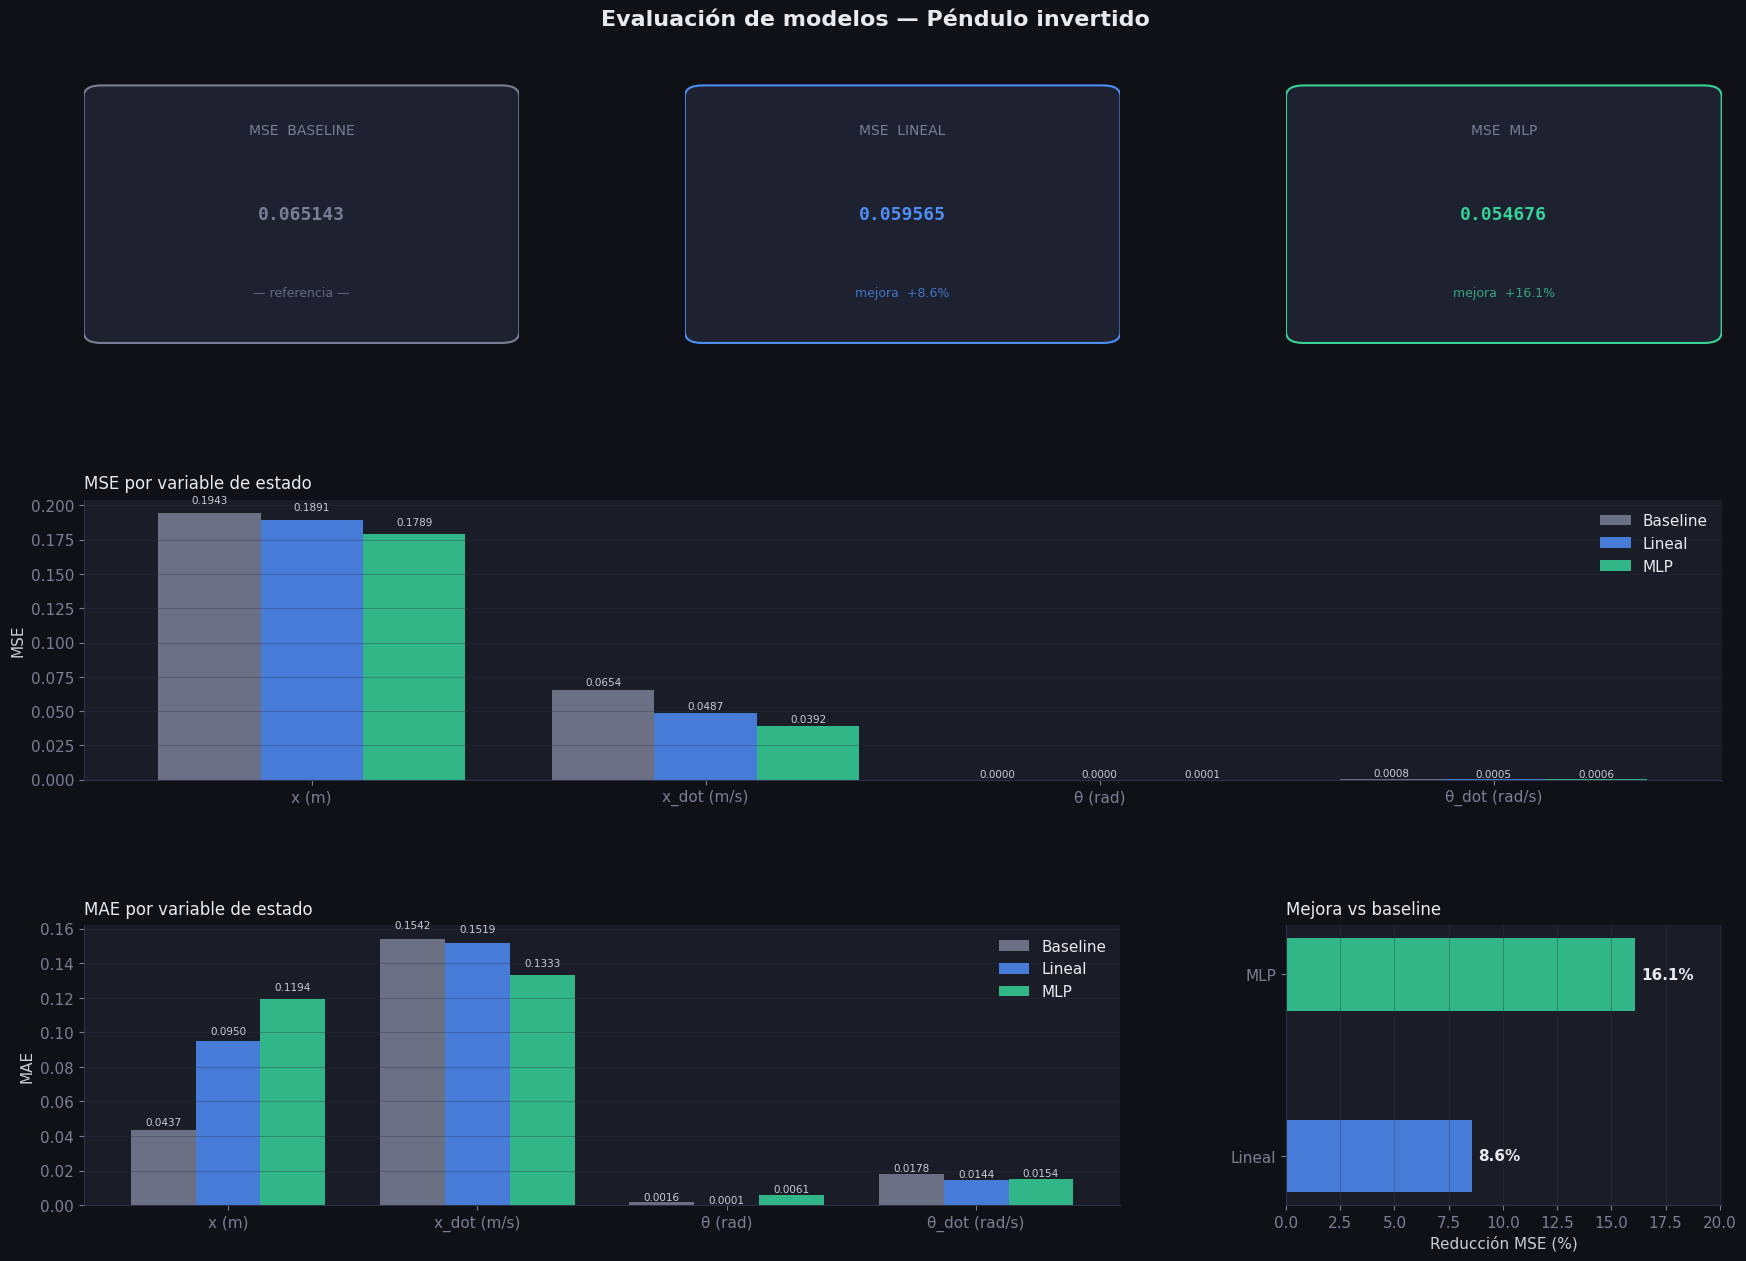

✓ Figura guardada como metricas_modelos.png


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3148',
    'axes.labelcolor':  '#c9cdd8',
    'xtick.color':      '#7a7f96',
    'ytick.color':      '#7a7f96',
    'text.color':       '#e8eaf0',
    'grid.color':       '#2e3148',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

COLORS = {
    'baseline': '#7a7f96',
    'lineal':   '#4e8ef7',
    'mlp':      '#36d399',
    'accent':   '#f6a623',
    'bg_card':  '#1e2130',
    'border':   '#2e3148',
}

labels = ["x (m)", "x_dot (m/s)", "θ (rad)", "θ_dot (rad/s)"]

# ── Cálculo de métricas ────────────────────────────────────────────────────────
Y_pred_base        = np.zeros_like(Y_test_real)
Y_pred_base[1:]    = Y_test_real[:-1]
Y_pred_base_valid  = Y_pred_base[1:]
Y_test_base_valid  = Y_test_real[1:]

mse_base = mean_squared_error(Y_test_base_valid, Y_pred_base_valid)
mse_lin  = mean_squared_error(Y_test_real, Y_lin_real)
mse_mlp  = mean_squared_error(Y_test_real, Y_mlp_real)

mejora_lin = (mse_base - mse_lin) / mse_base * 100
mejora_mlp = (mse_base - mse_mlp) / mse_base * 100

mse_vars = {
    'base': [mean_squared_error(Y_test_base_valid[:, i], Y_pred_base_valid[:, i]) for i in range(4)],
    'lin':  [mean_squared_error(Y_test_real[:, i], Y_lin_real[:, i])              for i in range(4)],
    'mlp':  [mean_squared_error(Y_test_real[:, i], Y_mlp_real[:, i])              for i in range(4)],
}
mae_vars = {
    'base': [mean_absolute_error(Y_test_base_valid[:, i], Y_pred_base_valid[:, i]) for i in range(4)],
    'lin':  [mean_absolute_error(Y_test_real[:, i], Y_lin_real[:, i])              for i in range(4)],
    'mlp':  [mean_absolute_error(Y_test_real[:, i], Y_mlp_real[:, i])              for i in range(4)],
}

# ── Layout ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13), facecolor='#0f1117')
fig.suptitle('Evaluación de modelos — Péndulo invertido',
             fontsize=16, fontweight='bold', color='#e8eaf0', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38,
                       top=0.93, bottom=0.06, left=0.06, right=0.97)

# ─ Tarjetas de MSE global ─────────────────────────────────────────────────────
def draw_card(ax, title, value, subtitle, color):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    box = FancyBboxPatch((0.04, 0.08), 0.92, 0.84,
                         boxstyle="round,pad=0.04",
                         facecolor=COLORS['bg_card'],
                         edgecolor=color, linewidth=1.5)
    ax.add_patch(box)
    ax.text(0.5, 0.80, title,    ha='center', va='center', fontsize=10,
            color='#7a7f96', fontweight='normal')
    ax.text(0.5, 0.50, f'{value:.6f}', ha='center', va='center',
            fontsize=13, color=color, fontweight='bold', fontfamily='monospace')
    ax.text(0.5, 0.22, subtitle, ha='center', va='center', fontsize=9,
            color=color, alpha=0.75)

ax_b  = fig.add_subplot(gs[0, 0])
ax_l  = fig.add_subplot(gs[0, 1])
ax_m  = fig.add_subplot(gs[0, 2])

draw_card(ax_b, 'MSE  BASELINE', mse_base, '— referencia —',         COLORS['baseline'])
draw_card(ax_l, 'MSE  LINEAL',   mse_lin,  f'mejora  {mejora_lin:+.1f}%', COLORS['lineal'])
draw_card(ax_m, 'MSE  MLP',      mse_mlp,  f'mejora  {mejora_mlp:+.1f}%', COLORS['mlp'])

# ─ Barras MSE por variable ────────────────────────────────────────────────────
ax_mse = fig.add_subplot(gs[1, :])
ax_mse.set_title('MSE por variable de estado', fontsize=12, pad=8, loc='left')

x      = np.arange(4)
width  = 0.26
bars_b = ax_mse.bar(x - width,     mse_vars['base'], width, label='Baseline', color=COLORS['baseline'], alpha=0.85)
bars_l = ax_mse.bar(x,             mse_vars['lin'],  width, label='Lineal',   color=COLORS['lineal'],   alpha=0.85)
bars_m = ax_mse.bar(x + width,     mse_vars['mlp'],  width, label='MLP',      color=COLORS['mlp'],      alpha=0.85)

for bars in [bars_b, bars_l, bars_m]:
    for bar in bars:
        h = bar.get_height()
        ax_mse.text(bar.get_x() + bar.get_width() / 2, h * 1.03,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=7.5, color='#c9cdd8')

ax_mse.set_xticks(x)
ax_mse.set_xticklabels(labels)
ax_mse.set_ylabel('MSE')
ax_mse.grid(axis='y', alpha=0.4)
ax_mse.legend(framealpha=0.15, edgecolor=COLORS['border'])
ax_mse.spines[['top','right']].set_visible(False)

# ─ Barras MAE por variable ────────────────────────────────────────────────────
ax_mae = fig.add_subplot(gs[2, :2])
ax_mae.set_title('MAE por variable de estado', fontsize=12, pad=8, loc='left')

bars_b2 = ax_mae.bar(x - width, mae_vars['base'], width, label='Baseline', color=COLORS['baseline'], alpha=0.85)
bars_l2 = ax_mae.bar(x,         mae_vars['lin'],  width, label='Lineal',   color=COLORS['lineal'],   alpha=0.85)
bars_m2 = ax_mae.bar(x + width, mae_vars['mlp'],  width, label='MLP',      color=COLORS['mlp'],      alpha=0.85)

for bars in [bars_b2, bars_l2, bars_m2]:
    for bar in bars:
        h = bar.get_height()
        ax_mae.text(bar.get_x() + bar.get_width() / 2, h * 1.03,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=7.5, color='#c9cdd8')

ax_mae.set_xticks(x)
ax_mae.set_xticklabels(labels)
ax_mae.set_ylabel('MAE')
ax_mae.grid(axis='y', alpha=0.4)
ax_mae.legend(framealpha=0.15, edgecolor=COLORS['border'])
ax_mae.spines[['top','right']].set_visible(False)

# ─ Mejora % (horizontal) ──────────────────────────────────────────────────────
ax_mej = fig.add_subplot(gs[2, 2])
ax_mej.set_title('Mejora vs baseline', fontsize=12, pad=8, loc='left')

modelos  = ['Lineal', 'MLP']
mejoras  = [mejora_lin, mejora_mlp]
colores  = [COLORS['lineal'], COLORS['mlp']]
bars_mej = ax_mej.barh(modelos, mejoras, color=colores, alpha=0.85, height=0.4)

for bar, val in zip(bars_mej, mejoras):
    ax_mej.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=11,
                color='#e8eaf0', fontweight='bold')

ax_mej.set_xlabel('Reducción MSE (%)')
ax_mej.grid(axis='x', alpha=0.4)
ax_mej.spines[['top','right']].set_visible(False)
ax_mej.set_xlim(0, max(mejoras) * 1.25)

plt.savefig('metricas_modelos.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✓ Figura guardada como metricas_modelos.png")

## Análisis de resultados

### MSE global — mejora limitada

El MLP mejora el MSE global aproximadamente un 16% respecto al modelo base, mientras que el modelo lineal mejora alrededor de un 8%. Es decir, sí hay mejora, pero tampoco es algo espectacular.

Esto indica que una parte importante de la dinámica del sistema ya está capturada simplemente por la inercia, es decir, por el hecho de que el sistema no cambia demasiado entre instantes. De hecho, el modelo base (que básicamente dice que todo se mantiene igual) ya da resultados bastante razonables.

---

### Análisis por variable — el error está en el carrito

Si miramos variable por variable, se ve claramente que el error viene sobre todo de:

- la posición del carrito \(x\)
- la velocidad del carrito \(\dot{x}\)

Los valores de error en estas variables son bastante más altos que en el ángulo:

- \(x\) (m) → error alto (~0.19)
- \(\dot{x}\) (m/s) → también relevante (~0.05)
- \(\theta\) y \(\dot{\theta}\) → errores muy pequeños (casi despreciables)

Esto tiene sentido físicamente. El ángulo del péndulo, sobre todo cerca del equilibrio, cambia poco entre instantes, por lo que incluso el modelo base lo predice muy bien.

Sin embargo, la posición del carrito depende directamente del voltaje aplicado, que introduce más variabilidad, por eso es más difícil de predecir.

---

### Lineal vs MLP — diferencia pequeña

La diferencia entre el modelo lineal y el MLP es bastante pequeña en general.

Esto puede indicar varias cosas:

- Para predicción a un paso, la no linealidad del sistema no es tan crítica.
- El modelo lineal ya captura bastante bien la dinámica en este contexto.
- El MLP podría necesitar más datos, más retardos o una arquitectura más compleja para aprovechar realmente su capacidad.

---

### MAE — mismo comportamiento, pero con matices

El error medio absoluto (MAE) sigue el mismo patrón que el MSE, pero hay un detalle interesante:

En la posición \(x\), el MLP tiene un MAE mayor que el baseline y el modelo lineal.

Esto es importante porque indica que:

- el MLP comete errores más grandes en algunos puntos
- aunque en general reduzca el MSE (porque corrige errores grandes puntuales)

Es decir, el MLP parece mejorar en términos de errores grandes (que penaliza mucho el MSE), pero puede empeorar en errores más frecuentes o medianos, lo que se refleja en el MAE.

---

### Conclusión parcial

En conjunto, los modelos de machine learning sí mejoran al baseline, pero la mejora es moderada.

Además, el principal reto del problema no está en el ángulo del péndulo, sino en la dinámica del carrito, que es donde realmente se concentran los errores.

Esto sugiere que el sistema, al menos en predicción a un paso, no exige modelos extremadamente complejos, aunque el MLP ofrece cierta ventaja en situaciones más exigentes.